In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
batch_size = 32
epochs = 15
# Binary classification (1 unit with sigmoid)
num_classes = 1
learning_rate = 0.001
input_size = 150

In [ ]:
train_dir = "/content/drive/MyDrive/HA_EXP/train"
test_dir = "/content/drive/MyDrive/HA_EXP/test"
test_image_path = "/content/drive/MyDrive/HA_EXP/test/dogs/dog_114.jpg"

In [ ]:
if not os.path.exists(train_dir):
    print(f" ERROR: The directory {train_dir} does not exist.")
    print("Please check your Google Drive path variable 'base_dir' above.")
else:
    print(f" Found dataset at: {base_dir}")

 Found dataset at: /content/drive/MyDrive/DNN/Dataset


In [ ]:
train_datagen = ImageDataGenerator(
        rescale=1./255,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True)

In [ ]:

batch_size = 32
input_size = 150  # Resize images to 150x150

# Augmentation for training data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Only rescaling for test data (no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load the data
print("Loading Training Data:")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(input_size, input_size),
    batch_size=batch_size,
    class_mode='binary'  # binary for 2 classes (e.g. Cat vs Dog)
)

print("Loading Test Data:")
validation_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(input_size, input_size),
    batch_size=batch_size,
    class_mode='binary'
)

Loading Training Data:
Found 557 images belonging to 2 classes.
Loading Test Data:
Found 140 images belonging to 2 classes.


In [ ]:

model = Sequential()

# Convolutional Layer 1
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(input_size, input_size, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolutional Layer 2
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolutional Layer 3
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Fully Connected Layers
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))  # Sigmoid for binary classification

# Compile the model
model.compile(loss='binary_crossentropy',
              optimizer=Adam(learning_rate=0.001),
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

epochs = 20

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    epochs=epochs
)


model.save('HA_EXP_classifier.h5')
print("Model saved successfully.")

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.5286 - loss: 0.6923 - val_accuracy: 0.6094 - val_loss: 0.6912
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 169ms/step - accuracy: 0.5938 - loss: 0.6886 - val_accuracy: 0.5156 - val_loss: 0.6916
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.5543 - loss: 0.6856 - val_accuracy: 0.4531 - val_loss: 0.7237
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 179ms/step - accuracy: 0.4688 - loss: 0.7036 - val_accuracy: 0.5078 - val_loss: 0.7187
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.5321 - loss: 0.6937 - val_accuracy: 0.6016 - val_loss: 0.6911
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 208ms/step - accuracy: 0.5625 - loss: 0.6662 - val_accuracy: 0.6328 - val_loss: 0.6833
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.5926 - loss: 0.6673 - val_accuracy: 0.6094 - val_loss: 0.7101
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step - accuracy: 0.6562 - loss: 0.6080 - val_accuracy: 0.6172 - v

Model saved successfully.


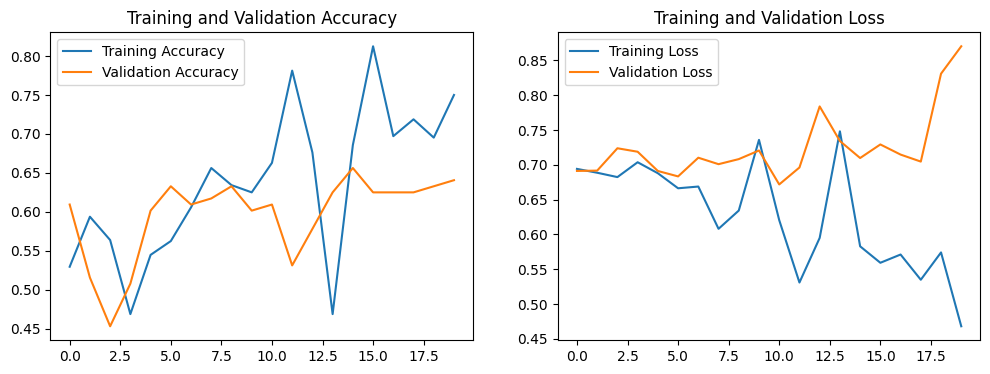

In [ ]:

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

 Looking for images in: /content/drive/MyDrive/HA_EXP/test
 Found specific image: dog_114.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


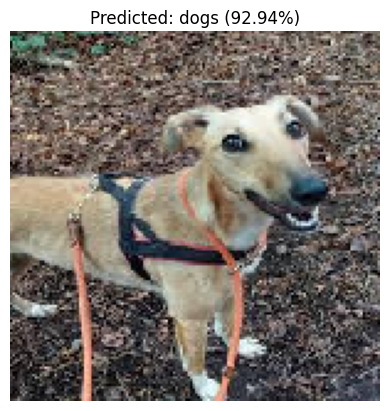

In [ ]:

import os
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

search_folder = test_dir
specific_image = "/content/drive/MyDrive/HA_EXP/test/dogs/dog_114.jpg"

print(f" Looking for images in: {search_folder}")

target_path = None
if os.path.exists(specific_image):
    target_path = specific_image
    print(f" Found specific image: {os.path.basename(target_path)}")
else:

    print(f" specific image not found. Searching subfolders in {search_folder}...")
    if os.path.exists(search_folder):
        for folder_name in os.listdir(search_folder):
            folder_path = os.path.join(search_folder, folder_name)
            if os.path.isdir(folder_path) and len(os.listdir(folder_path)) > 0:
                target_path = os.path.join(folder_path, os.listdir(folder_path)[0])
                print(f"Auto-found image: {target_path}")
                break


if target_path and os.path.exists(target_path):
    # Load & Preprocess
    img = image.load_img(target_path, target_size=(150, 150))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Predict
    prediction = model.predict(img_array)
    confidence = prediction[0][0]

    # Get Labels (e.g., {'cats': 0, 'dogs': 1})
    labels = {v: k for k, v in train_generator.class_indices.items()}

    # Interpret
    if confidence > 0.5:
        predicted_class = labels[1]
        val = confidence
    else:
        predicted_class = labels[0]
        val = 1 - confidence

    # Show
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class} ({val:.2%})")
    plt.axis('off')
    plt.show()
else:
    print(f" ERROR: Still could not find any images in {search_folder}")
    print("Please check if your Google Drive is mounted and the 'HA_EXP' folder exists.")

In [ ]:

import os
save_path = "/content/drive/MyDrive/HA_EXP/HA_EXP_classifier.h5"
model.save(save_path)
if os.path.exists(save_path):
    print(f" Success! Model saved to Google Drive at:\n{save_path}")
else:
    print(" Error: Could not save to Drive. Check your permissions.")

 Success! Model saved to Google Drive at:
/content/drive/MyDrive/HA_EXP/HA_EXP_classifier.h5
